# LINK VIDEO : 


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor


In [2]:
#Load Dataset
targets = pd.read_csv("A_targets.csv")
features = pd.read_csv("A.csv")  

#Merge berdasarkan Student_ID
df = pd.merge(features, targets, on="Student_ID")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

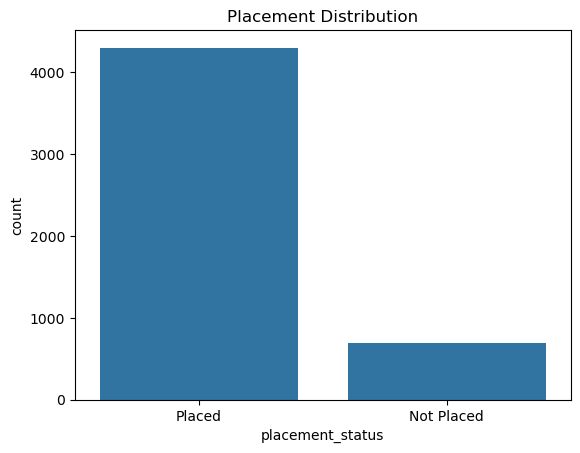

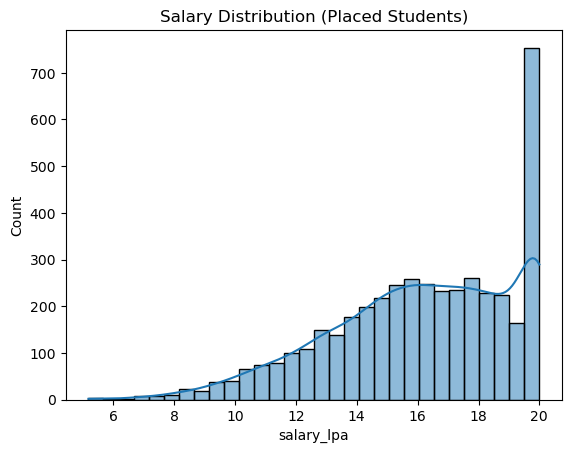

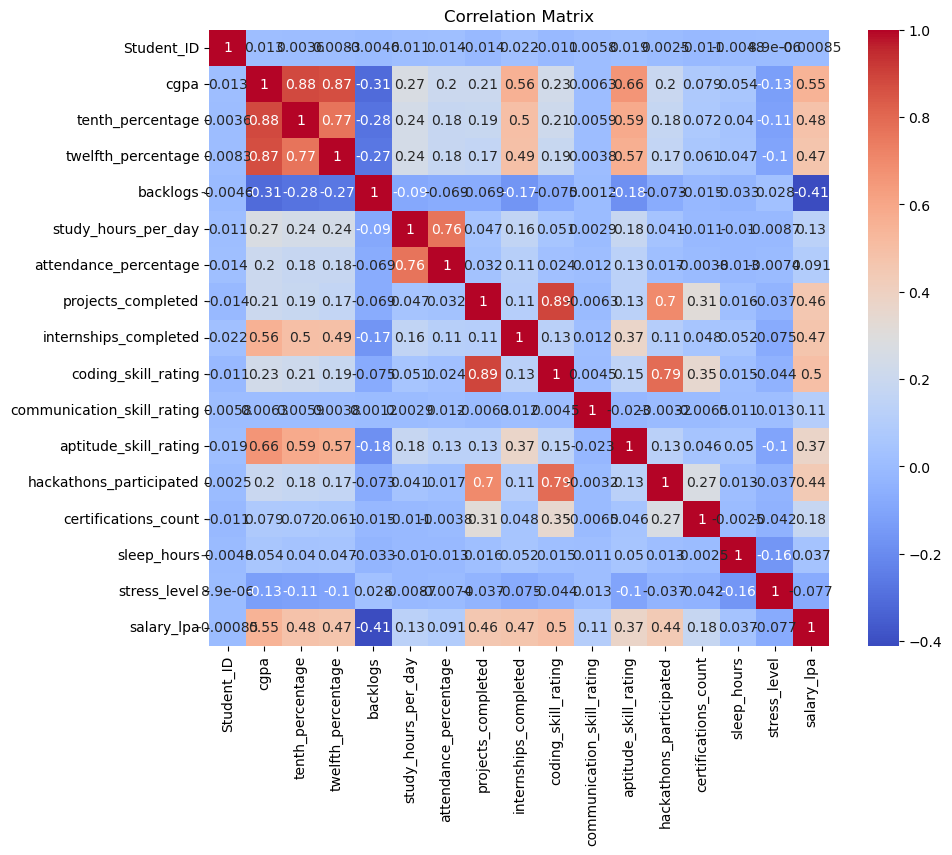

In [3]:
#EDA
print(df.info())
print(df.describe())

#Distribusi placement
sns.countplot(x="placement_status", data=df)
plt.title("Placement Distribution")
plt.show()

#Distribusi salary (Placed only)
sns.histplot(df[df["placement_status"]=="Placed"]["salary_lpa"], bins=30, kde=True)
plt.title("Salary Distribution (Placed Students)")
plt.show()

#Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [4]:
#Missing Value
print(df.isnull().sum())

#numerik
df.fillna(df.median(numeric_only=True), inplace=True)

#kategorikal
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
placement_status                  0
salary_lpa                        0
dtype: int64


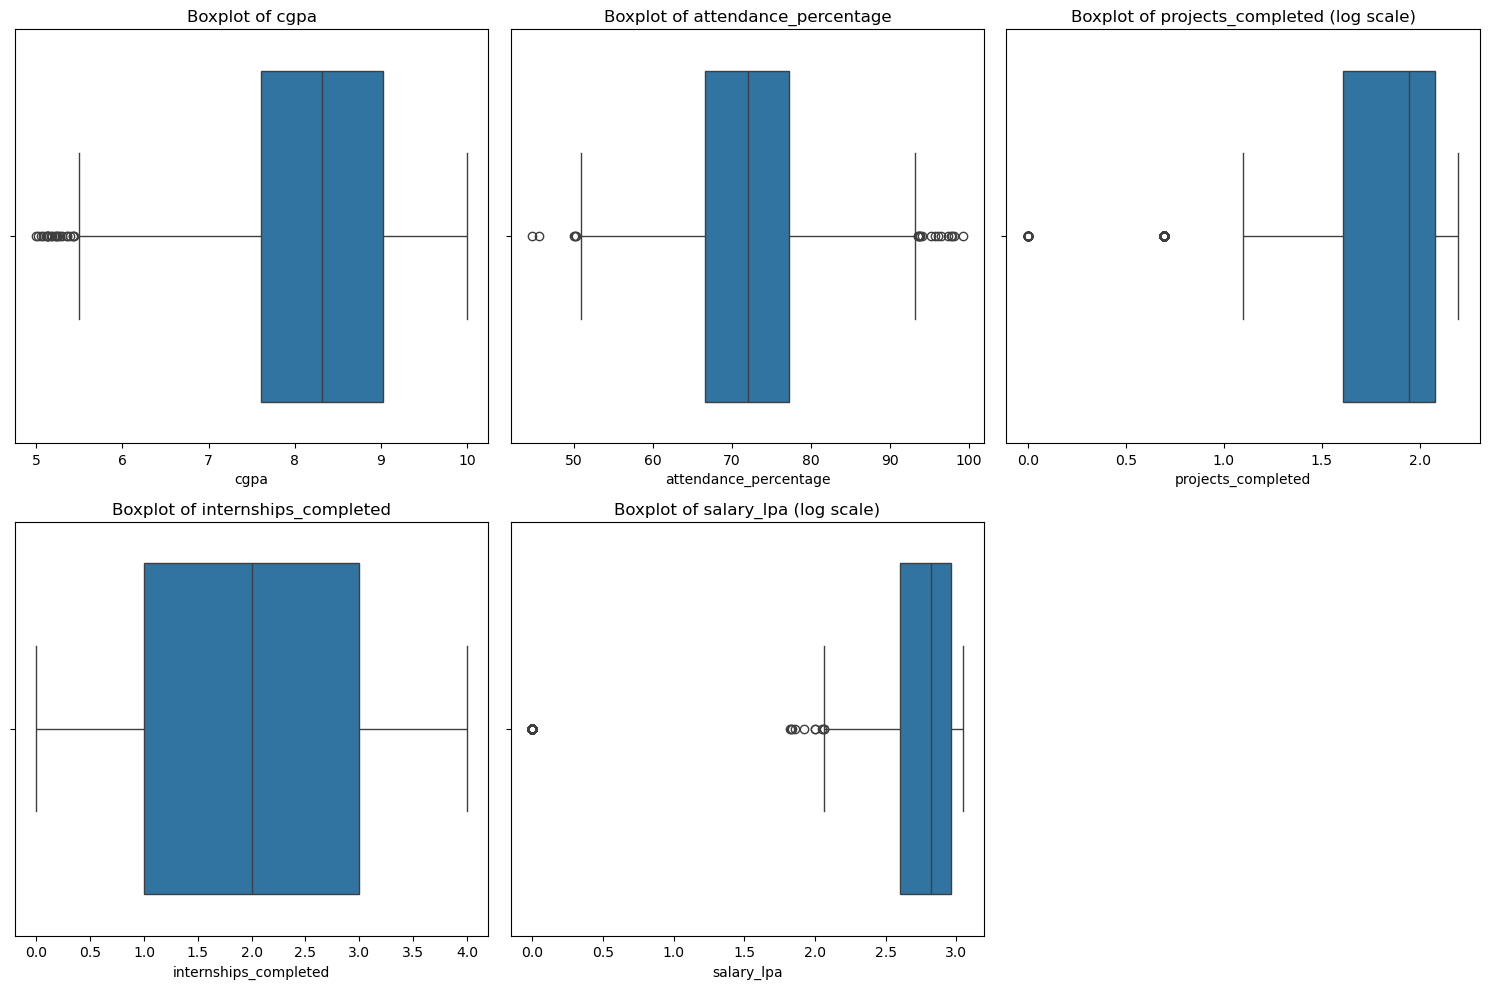

In [5]:
#Outlier
important_cols = ["cgpa", "attendance_percentage", 
                  "projects_completed", "internships_completed", 
                  "salary_lpa"]

n_cols = 3
n_rows = int(np.ceil(len(important_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(important_cols):
    # Gunakan log scale untuk variabel dengan range besar
    if col in ["salary_lpa", "projects_completed"]:
        sns.boxplot(x=np.log1p(df[col]), ax=axes[i])
        axes[i].set_title(f"Boxplot of {col} (log scale)")
    else:
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Boxplot of {col}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [6]:
#Feature Engineering
df["placement_binary"] = df["placement_status"].apply(lambda x: 1 if x=="Placed" else 0)

#Cek imbalance
print(df["placement_binary"].value_counts(normalize=True))


placement_binary
1    0.8606
0    0.1394
Name: proportion, dtype: float64


In [7]:
# Split Data
X = df.drop(columns=["placement_status","salary_lpa","placement_binary"])
y_class = df["placement_binary"]

# regresi hanya untuk yang placed
df_reg = df[df["placement_binary"] == 1]

X_reg = df_reg.drop(columns=["placement_status","salary_lpa","placement_binary"])
y_reg = df_reg["salary_lpa"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [8]:
#Preprocessing Pipeline
num_features = X.select_dtypes(include=["int64","float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

LogReg Accuracy: 0.895, F1: 0.940


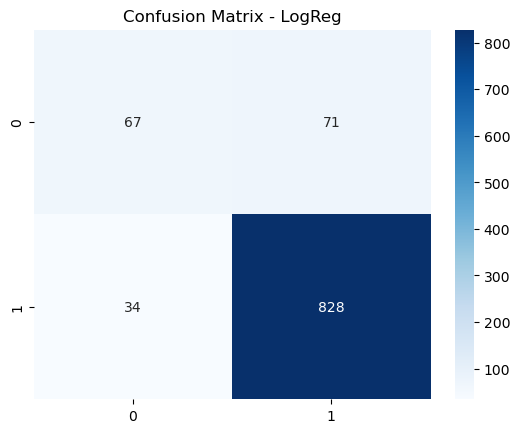

Classification Report - LogReg
              precision    recall  f1-score   support

  Not Placed       0.66      0.49      0.56       138
      Placed       0.92      0.96      0.94       862

    accuracy                           0.90      1000
   macro avg       0.79      0.72      0.75      1000
weighted avg       0.89      0.90      0.89      1000

------------------------------------------------------------
RF Accuracy: 0.888, F1: 0.937


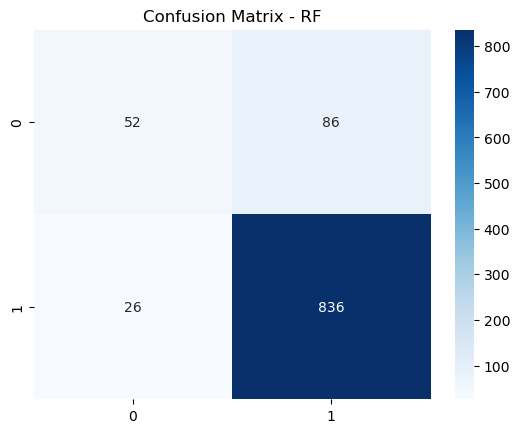

Classification Report - RF
              precision    recall  f1-score   support

  Not Placed       0.67      0.38      0.48       138
      Placed       0.91      0.97      0.94       862

    accuracy                           0.89      1000
   macro avg       0.79      0.67      0.71      1000
weighted avg       0.87      0.89      0.87      1000

------------------------------------------------------------


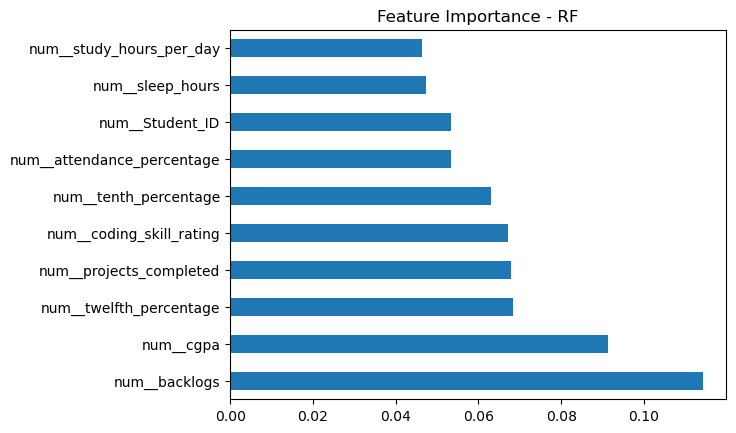

GB Accuracy: 0.886, F1: 0.935


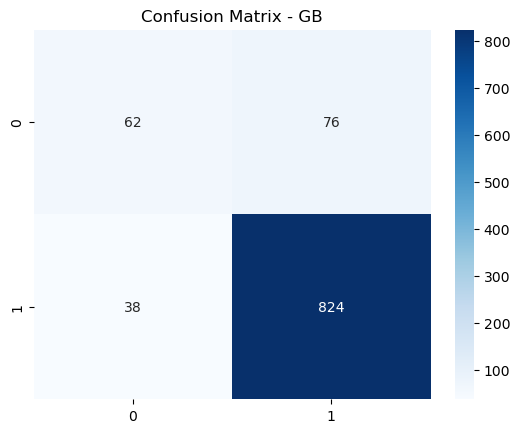

Classification Report - GB
              precision    recall  f1-score   support

  Not Placed       0.62      0.45      0.52       138
      Placed       0.92      0.96      0.94       862

    accuracy                           0.89      1000
   macro avg       0.77      0.70      0.73      1000
weighted avg       0.87      0.89      0.88      1000

------------------------------------------------------------


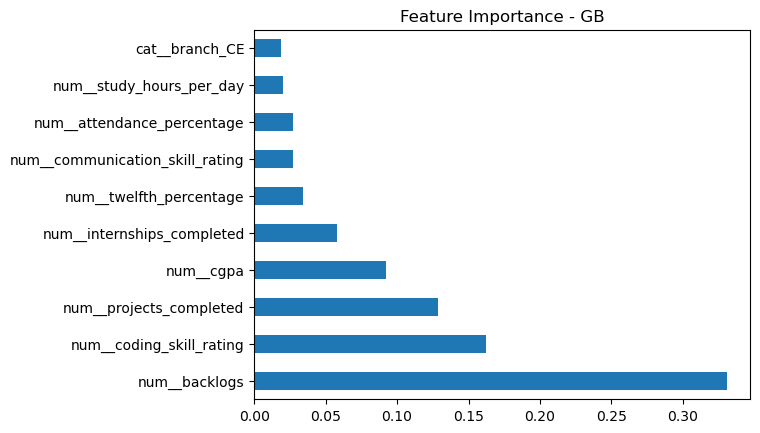

,model,accuracy,f1
0,LogReg,0.895,0.940375
1,RF,0.888,0.937220
2,GB,0.886,0.935301


In [9]:
#Modeling - Classification
models_class = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42)
}

results_class = []

for name, model in models_class.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train_c, y_train_c)
    y_pred = clf.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    results_class.append({"model": name, "accuracy": acc, "f1": f1})
    print(f"{name} Accuracy: {acc:.3f}, F1: {f1:.3f}")

    #Confusion Matrix
    cm = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    #Classification Report
    print(f"Classification Report - {name}")
    print(classification_report(y_test_c, y_pred, target_names=["Not Placed","Placed"]))
    print("-"*60)

    #Feature importance (khusus RF/GB)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:10]
        feat_imp.plot(kind='barh')
        plt.title(f"Feature Importance - {name}")
        plt.show()

pd.DataFrame(results_class)

LinReg RMSE: 1.407, R2: 0.772


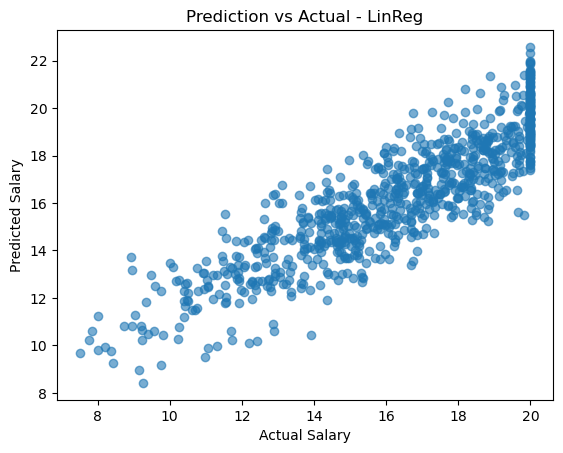

RFReg RMSE: 1.507, R2: 0.738


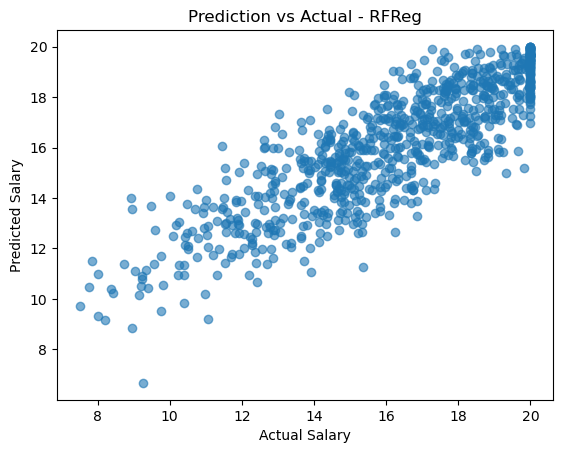

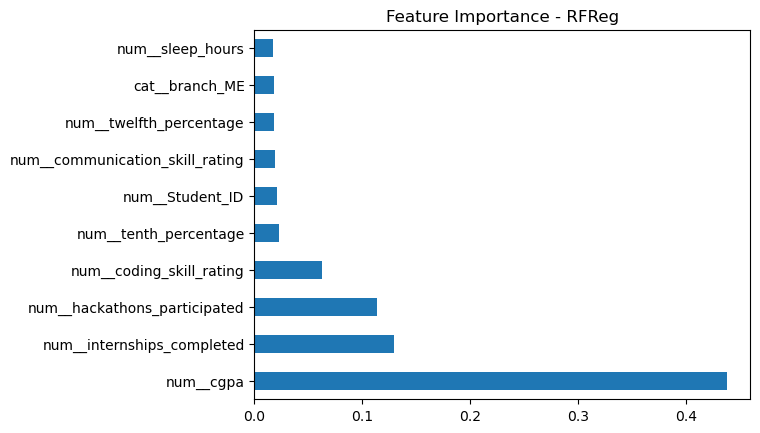

GBReg RMSE: 1.400, R2: 0.774


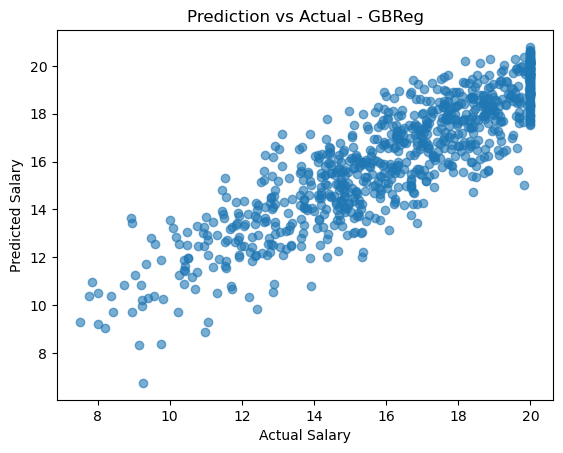

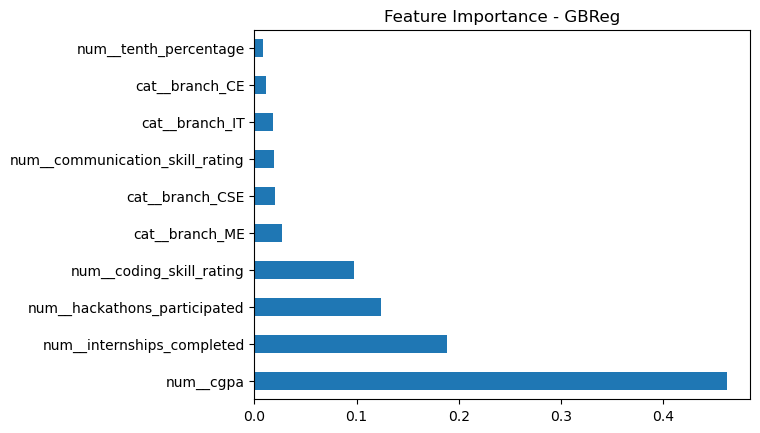

,model,RMSE,R2
0,LinReg,1.407142,0.771610
1,RFReg,1.506992,0.738047
2,GBReg,1.400072,0.773899


In [10]:
#Modeling - Regression
models_reg = {
    "LinReg": LinearRegression(),
    "RFReg": RandomForestRegressor(random_state=42),
    "GBReg": GradientBoostingRegressor(random_state=42)
}

results_reg = []

for name, model in models_reg.items():
    reg = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    reg.fit(X_train_r, y_train_r)
    y_pred_r = reg.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    r2 = r2_score(y_test_r, y_pred_r)
    results_reg.append({"model": name, "RMSE": rmse, "R2": r2})
    print(f"{name} RMSE: {rmse:.3f}, R2: {r2:.3f}")

    #Visualisasi 
    plt.scatter(y_test_r, y_pred_r, alpha=0.6)
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title(f"Prediction vs Actual - {name}")
    plt.show()

    # Feature importance (khusus RF/GB)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_names = reg.named_steps["preprocessor"].get_feature_names_out()
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:10]
        feat_imp.plot(kind='barh')
        plt.title(f"Feature Importance - {name}")
        plt.show()

pd.DataFrame(results_reg)

# Interpretasi Hasil Klasifikasi
#### Imbalance Data  
Proporsi kelas: 86% Placed vs 14% Not Placed.  
Ini membuat metrik F1‑score lebih relevan daripada sekadar accuracy, karena F1 menyeimbangkan precision dan recall pada kelas minoritas. 

#### Logistic Regression (baseline)  
Accuracy: 0.895, F1: 0.940.  
Model baseline ini sudah sangat kuat, mampu menangkap pola linear dengan baik. Precision tinggi (0.92) dan recall tinggi (0.96) untuk kelas Placed menunjukkan model jarang salah mengklasifikasikan mahasiswa yang benar‑benar ditempatkan.  

#### Random Forest & Gradient Boosting  
Accuracy: 0.888 - 0.886, F1: 0.937 - 0.935.  
Performa mirip Logistic Regression, sedikit lebih rendah. Namun keunggulannya ada di interpretasi fitur: bisa menunjukkan variabel mana yang paling berpengaruh terhadap placement (misalnya CGPA, attendance, skill scores).

#### Kesimpulan Klasifikasi  
Logistic Regression cocok sebagai baseline deployment karena sederhana dan akurat. RF/GB bisa dipakai jika interpretasi fitur atau non‑linearitas dianggap penting.

# Interpretasi Hasil Regresi
#### Linear Regression (baseline)  
RMSE: 1.407, R²: 0.772.  
Model linear cukup baik, menjelaskan sekitar 77% variasi salary. Error rata rata sekitar 1.4 LPA.

#### Random Forest Regressor  
RMSE: 1.507, R²: 0.738.  
Sedikit lebih buruk dari Linear Regression, tapi berguna untuk melihat feature importance.

#### Gradient Boosting Regressor  
RMSE: 1.400, R²: 0.774.  
Performa terbaik, error paling kecil dan R² tertinggi. Cocok jadi model utama untuk salary prediction.

#### Kesimpulan Regresi  
GBReg adalah kandidat terbaik untuk deployment salary prediction. LinReg tetap berguna sebagai baseline, RFReg untuk interpretasi.

#### Alasan Pemilihan Fitur
Akademik: CGPA, attendance, project count -> indikator langsung performa akademik.  
Skill: technical & soft skill scores -> relevan dengan employability.  
Lifestyle: sleep hours, stress, communication -> bisa memengaruhi performa.  
Target: placement status (binary) untuk klasifikasi, salary untuk regresi.  